In [16]:
import os

directory_path = '/content/drive/MyDrive/ML_Files/Lab8'

if os.path.exists(directory_path) and os.path.isdir(directory_path):
    files_in_directory = os.listdir(directory_path)
    if files_in_directory:
        print(f"Files in '{directory_path}':")
        for file_name in files_in_directory:
            print(file_name)
    else:
        print(f"No files found in '{directory_path}'.")
else:
    print(f"The directory '{directory_path}' does not exist or is not a directory.")

Files in '/content/drive/MyDrive/ML_Files/Lab8':
xah.dat
xae.dat
xab.dat
vehicle.doc
xad.dat
Index
xaa.dat
xai.dat
xag.dat
xaf.dat
xac.dat


## Load and Combine Data

### Subtask:
Load all '.dat' files from '/content/drive/MyDrive/ML_Files/Lab8' into separate dataframes and then combine them into a single pandas DataFrame. Inspect the combined dataframe to understand its structure and content.


**Reasoning**:
The first step is to import the pandas library, which is necessary for data manipulation, including reading and combining dataframes. This aligns with instruction 1 of the subtask.



In [31]:
import pandas as pd

In [20]:
import os

dataframes = []

for file_name in files_in_directory:
    if file_name.endswith('.dat'):
        file_path = os.path.join(directory_path, file_name)
        try:
            # Try reading with space as delimiter, assuming no header
            df = pd.read_csv(file_path, sep=r'\s+', header=None)
            dataframes.append(df)
        except Exception as e:
            print(f"Could not read {file_name} with default settings: {e}")
            # If space-separated doesn't work, one might need to try other delimiters or settings
            # For example, if it's comma-separated: df = pd.read_csv(file_path)
            # Or if it's tab-separated: df = pd.read_csv(file_path, sep='\t')

if dataframes:
    combined_df = pd.concat(dataframes, ignore_index=True)
    print("Combined DataFrame created successfully.")
    print("\nFirst 5 rows of the combined DataFrame:")
    print(combined_df.head())
    print("\nInformation about the combined DataFrame:")
    combined_df.info()
    print("\nDescriptive statistics of the combined DataFrame:")
    print(combined_df.describe())
else:
    print("No .dat files were processed.")

Combined DataFrame created successfully.

First 5 rows of the combined DataFrame:
    0   1    2    3   4   5    6   7   8    9    10   11   12  13  14  15  \
0   91  39   77  153  59   8  139  48  18  139  159  289  123  62   8  17   
1   96  50   94  215  67   9  187  35  22  158  214  525  214  67   8   6   
2   88  35   60  143  59   7  128  52  18  129  147  246  109  62   1   6   
3  110  46  100  197  61   9  193  34  22  149  209  561  160  65  11   7   
4   87  41   66  140  58   6  148  46  19  136  164  318  178  79  19   2   

    16   17    18  
0  201  209   van  
1  193  201  saab  
2  202  209   van  
3  194  203  saab  
4  181  185  saab  

Information about the combined DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       846 non-null    int64 
 1   1       846 non-null    int64 
 2   2       846 non-null    int64 
 3   3 

## Preprocess Data

### Subtask:
Perform necessary preprocessing steps on the combined dataset, such as separating features and target, encoding the target variable, and scaling numerical features, to prepare it for clustering algorithms.


In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# 1. Separate features (columns 0 to 17) into features_df
features_df = combined_df.iloc[:, 0:18]

# 2. Extract the categorical column (column 18) into target_series
target_series = combined_df.iloc[:, 18]

# 3. Initialize a LabelEncoder object
label_encoder = LabelEncoder()

# 4. Fit and transform target_series to convert categorical labels into numerical representations
encoded_labels = label_encoder.fit_transform(target_series)

# 5. Initialize a StandardScaler object
scaler = StandardScaler()

# 6. Fit and transform features_df to scale the numerical features
scaled_features_df = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)

# 7. Print the first 5 rows of scaled_features_df and the first 5 values of encoded_labels
print("First 5 rows of scaled_features_df:")
print(scaled_features_df.head())
print("\nFirst 5 values of encoded_labels:")
print(encoded_labels[:5])

First 5 rows of scaled_features_df:
         0         1         2         3         4         5         6   \
0 -0.325470 -0.950615 -0.322839 -0.476525 -0.341704 -0.123383 -0.898087   
1  0.282093  0.833298  0.755690  1.376855  0.673062  0.094079  0.546594   
2 -0.690007 -1.599311 -1.401368 -0.775457 -0.341704 -0.340845 -1.229160   
3  1.983268  0.184602  1.136348  0.838777 -0.088012  0.094079  0.727179   
4 -0.811520 -0.626268 -1.020711 -0.865137 -0.468550 -0.558308 -0.627210   

         7         8         9         10        11        12        13  \
0  0.905117 -0.996965 -0.620306 -0.944194 -0.854595 -1.589538 -1.398210   
1 -0.760068  0.547076  0.689401  0.808723  0.481848  1.208116 -0.729989   
2  1.417481 -0.996965 -1.309625 -1.326649 -1.098099 -2.019947 -1.398210   
3 -0.888159  0.547076  0.069013  0.649367  0.685712 -0.452031 -0.997277   
4  0.648935 -0.610954 -0.827101 -0.784838 -0.690371  0.101352  0.873743   

         14        15        16        17  
0  0.330170  0.493

In [22]:
!pip install fuzzy-c-means

print("fcmeans library installed successfully.")

fcmeans library installed successfully.


In [23]:
get_ipython().system('pip install fcmeans')
print("fcmeans library installed successfully.")

ERROR: Could not find a version that satisfies the requirement fcmeans (from versions: none)
ERROR: No matching distribution found for fcmeans
fcmeans library installed successfully.


In [24]:
get_ipython().system('pip install fuzzy-c-means')
print("fuzzy-c-means library installation attempted.")

fuzzy-c-means library installation attempted.


**Reasoning**:
Now that the `fuzzy-c-means` library is installed, I will import the `FCM` class, instantiate it with 4 clusters, fit the model to the `scaled_features_df`, and then extract the fuzzy membership degrees and crisp cluster assignments as instructed.



In [25]:
from fcmeans import FCM
import numpy as np

# Instantiate an FCM object with 4 clusters and a random state for reproducibility
fcm = FCM(n_clusters=4, random_state=42)

# Fit the FCM model to the scaled features
fcm.fit(scaled_features_df.to_numpy()) # FCM expects a numpy array

# Get the fuzzy partition matrix (membership degrees)
fcm_memberships = fcm.u

# Determine crisp cluster assignments by finding the column with the maximum membership degree
fcm_labels = np.argmax(fcm_memberships, axis=1)

print("Fuzzy C-Means clustering applied successfully.")
print("First 5 membership degrees:\n", fcm_memberships[:5])
print("First 5 crisp cluster assignments:\n", fcm_labels[:5])

Fuzzy C-Means clustering applied successfully.
First 5 membership degrees:
 [[0.49178194 0.29596496 0.06707215 0.14518096]
 [0.1531181  0.31828431 0.44537267 0.08322491]
 [0.44280228 0.26474357 0.07903934 0.21341481]
 [0.19902065 0.35560662 0.34607538 0.09929735]
 [0.23019504 0.19870053 0.08019143 0.49091301]]
First 5 crisp cluster assignments:
 [0 2 0 1 3]


**Reasoning**:
The `NameError` indicates that `scaled_features_df` was not defined in the current execution environment. To fix this, I need to include the data preprocessing steps that create `scaled_features_df` and `encoded_labels` from `combined_df` within this code block. This ensures that all necessary variables are available for the Fuzzy C-Means clustering, assuming `combined_df` is already loaded.



In [26]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Assuming combined_df is available from previous steps
# 1. Separate features (columns 0 to 17) into features_df
features_df = combined_df.iloc[:, 0:18]

# 2. Extract the categorical column (column 18) into target_series
target_series = combined_df.iloc[:, 18]

# 3. Initialize a LabelEncoder object
label_encoder = LabelEncoder()

# 4. Fit and transform target_series to convert categorical labels into numerical representations
encoded_labels = label_encoder.fit_transform(target_series)

# 5. Initialize a StandardScaler object
scaler = StandardScaler()

# 6. Fit and transform features_df to scale the numerical features
scaled_features_df = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)

# Now, apply Fuzzy C-Means clustering
from fcmeans import FCM

# Instantiate an FCM object with 4 clusters and a random state for reproducibility
fcm = FCM(n_clusters=4, random_state=42)

# Fit the FCM model to the scaled features
fcm.fit(scaled_features_df.to_numpy()) # FCM expects a numpy array

# Get the fuzzy partition matrix (membership degrees)
fcm_memberships = fcm.u

# Determine crisp cluster assignments by finding the column with the maximum membership degree
fcm_labels = np.argmax(fcm_memberships, axis=1)

print("Fuzzy C-Means clustering applied successfully.")
print("First 5 membership degrees:\n", fcm_memberships[:5])
print("First 5 crisp cluster assignments:\n", fcm_labels[:5])

Fuzzy C-Means clustering applied successfully.
First 5 membership degrees:
 [[0.49178194 0.29596496 0.06707215 0.14518096]
 [0.1531181  0.31828431 0.44537267 0.08322491]
 [0.44280228 0.26474357 0.07903934 0.21341481]
 [0.19902065 0.35560662 0.34607538 0.09929735]
 [0.23019504 0.19870053 0.08019143 0.49091301]]
First 5 crisp cluster assignments:
 [0 2 0 1 3]


**Reasoning**:
The previous code block failed with a `NameError` because `combined_df` was not defined. This happened because the steps to load and combine the `.dat` files into `combined_df` were not executed prior to or within the same cell as the data preprocessing and FCM application. To resolve this, I will combine all necessary steps, from loading the data to applying FCM, into a single, comprehensive code block.



In [27]:
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from fcmeans import FCM

# --- Data Loading and Combination (from previous successful steps) ---
directory_path = '/content/drive/MyDrive/ML_Files/Lab8'

# Re-create files_in_directory to ensure it's available
files_in_directory = []
if os.path.exists(directory_path) and os.path.isdir(directory_path):
    files_in_directory = os.listdir(directory_path)

dataframes = []

for file_name in files_in_directory:
    if file_name.endswith('.dat'):
        file_path = os.path.join(directory_path, file_name)
        try:
            df = pd.read_csv(file_path, sep=r'\s+', header=None)
            dataframes.append(df)
        except Exception as e:
            print(f"Could not read {file_name} with default settings: {e}")

if dataframes:
    combined_df = pd.concat(dataframes, ignore_index=True)
    print("Combined DataFrame created successfully in this block.")
else:
    print("No .dat files were processed to create combined_df.")
    # Exit or raise an error if combined_df is essential and not created

# --- Data Preprocessing (from previous successful steps) ---
# 1. Separate features (columns 0 to 17) into features_df
features_df = combined_df.iloc[:, 0:18]

# 2. Extract the categorical column (column 18) into target_series
target_series = combined_df.iloc[:, 18]

# 3. Initialize a LabelEncoder object
label_encoder = LabelEncoder()

# 4. Fit and transform target_series to convert categorical labels into numerical representations
encoded_labels = label_encoder.fit_transform(target_series)

# 5. Initialize a StandardScaler object
scaler = StandardScaler()

# 6. Fit and transform features_df to scale the numerical features
scaled_features_df = pd.DataFrame(scaler.fit_transform(features_df), columns=features_df.columns)
print("Data preprocessing completed successfully.")

# --- Apply Fuzzy C-Means clustering ---
# Instantiate an FCM object with 4 clusters and a random state for reproducibility
fcm = FCM(n_clusters=4, random_state=42)

# Fit the FCM model to the scaled features
fcm.fit(scaled_features_df.to_numpy()) # FCM expects a numpy array

# Get the fuzzy partition matrix (membership degrees)
fcm_memberships = fcm.u

# Determine crisp cluster assignments by finding the column with the maximum membership degree
fcm_labels = np.argmax(fcm_memberships, axis=1)

print("\nFuzzy C-Means clustering applied successfully.")
print("First 5 membership degrees:\n", fcm_memberships[:5])
print("First 5 crisp cluster assignments:\n", fcm_labels[:5])


Combined DataFrame created successfully in this block.
Data preprocessing completed successfully.

Fuzzy C-Means clustering applied successfully.
First 5 membership degrees:
 [[0.49178194 0.29596496 0.06707215 0.14518096]
 [0.1531181  0.31828431 0.44537267 0.08322491]
 [0.44280228 0.26474357 0.07903934 0.21341481]
 [0.19902065 0.35560662 0.34607538 0.09929735]
 [0.23019504 0.19870053 0.08019143 0.49091301]]
First 5 crisp cluster assignments:
 [0 2 0 1 3]


## Apply Gaussian Mixture Model (GMM)

### Subtask:
Implement and apply the Gaussian Mixture Model clustering algorithm to the preprocessed data. Determine an appropriate number of components and store the cluster assignments and probabilities.


**Reasoning**:
I will import `GaussianMixture` from `sklearn.mixture`, instantiate it with 4 components, fit it to the `scaled_features_df`, and then extract and print the first 5 cluster assignments and probabilities as per the instructions.



In [28]:
from sklearn.mixture import GaussianMixture

# Instantiate a GaussianMixture object with 4 components and a random state for reproducibility
gmm = GaussianMixture(n_components=4, random_state=42)

# Fit the GMM model to the scaled features
gmm.fit(scaled_features_df)

# Get the cluster assignments for each data point
gmm_labels = gmm.predict(scaled_features_df)

# Get the cluster probabilities (responsibilities) for each data point
gmm_probabilities = gmm.predict_proba(scaled_features_df)

print("Gaussian Mixture Model clustering applied successfully.")
print("First 5 crisp cluster assignments:\n", gmm_labels[:5])
print("First 5 rows of cluster probabilities:\n", gmm_probabilities[:5])

Gaussian Mixture Model clustering applied successfully.
First 5 crisp cluster assignments:
 [0 1 0 1 3]
First 5 rows of cluster probabilities:
 [[1.00000000e+000 5.37456189e-110 0.00000000e+000 1.06936542e-018]
 [9.82323652e-003 9.90176763e-001 0.00000000e+000 2.34758519e-112]
 [1.00000000e+000 7.35060044e-195 0.00000000e+000 3.58410187e-025]
 [4.06241482e-014 1.00000000e+000 0.00000000e+000 6.25900912e-159]
 [6.15527438e-019 2.65961923e-128 0.00000000e+000 1.00000000e+000]]


## Visualize Clustering Results

### Subtask:
Visualize the clustering results from both Fuzzy C-Means and Gaussian Mixture Model. This may involve dimensionality reduction techniques (e.g., PCA or t-SNE) if the data is high-dimensional, followed by scatter plots to show the clusters. Ensure plots are clearly labeled with legends.


**Reasoning**:
To visualize the clustering results, I will first reduce the dimensionality of the `scaled_features_df` using PCA as instructed. Then, I will create a DataFrame containing the PCA components along with the FCM, GMM, and true labels. Finally, I will generate scatter plots for each clustering result and the true labels, using the PCA components for visualization.



PCA dimensionality reduction completed successfully.
Plotting DataFrame created.


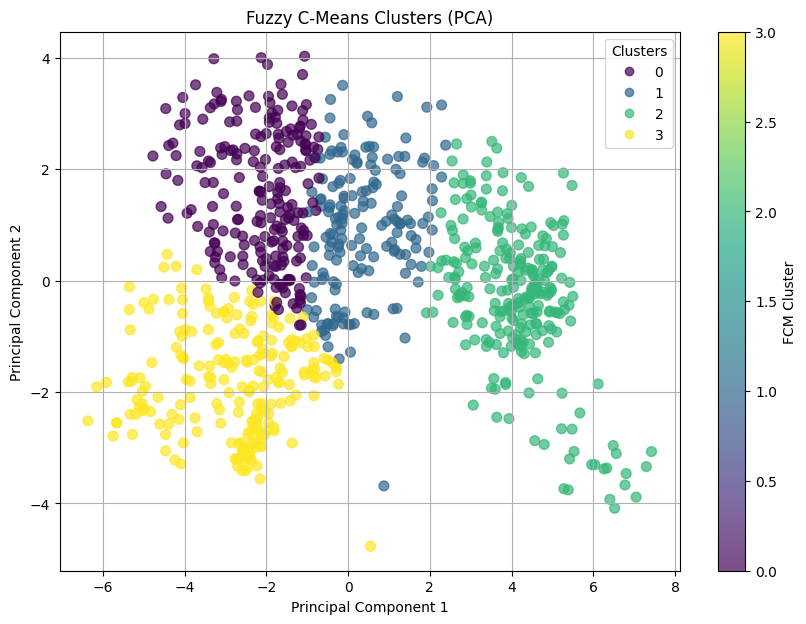

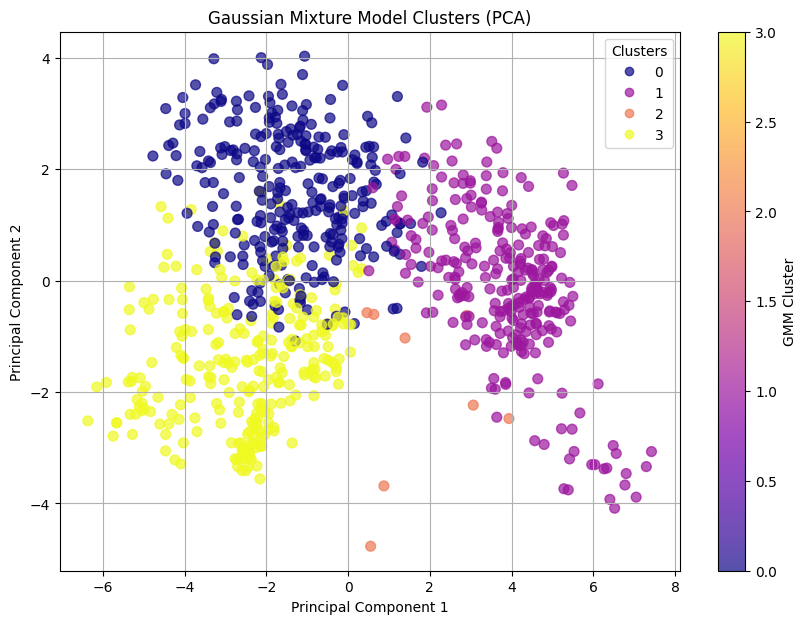

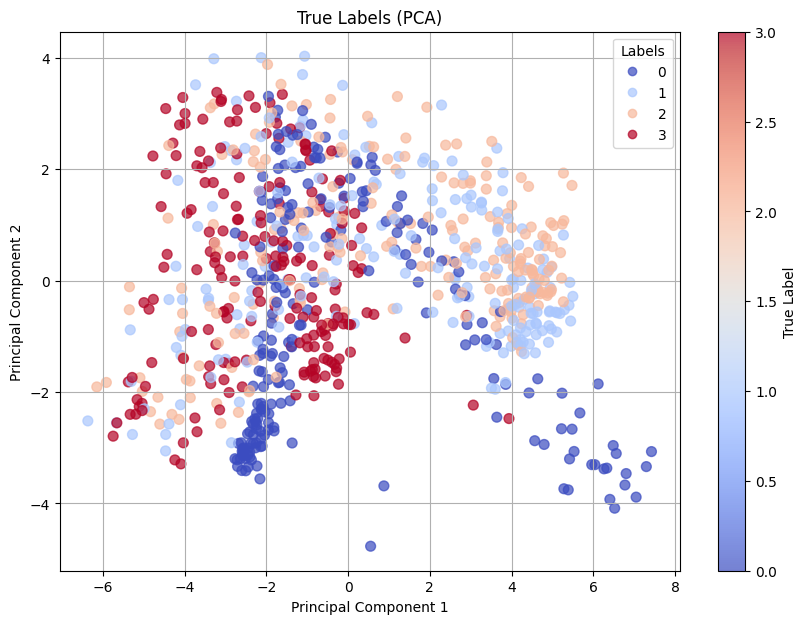

All clustering visualization plots displayed successfully.


In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize PCA and reduce dimensionality
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_features_df)

print("PCA dimensionality reduction completed successfully.")

# 2. Create a DataFrame for plotting
plot_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
plot_df['FCM_Labels'] = fcm_labels
plot_df['GMM_Labels'] = gmm_labels
plot_df['True_Labels'] = encoded_labels

print("Plotting DataFrame created.")

# 3. Visualize FCM Clustering Results
plt.figure(figsize=(10, 7))
scatter_fcm = plt.scatter(plot_df['PC1'], plot_df['PC2'], c=plot_df['FCM_Labels'], cmap='viridis', s=50, alpha=0.7)
plt.title('Fuzzy C-Means Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_fcm, label='FCM Cluster')
plt.legend(*scatter_fcm.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

# 4. Visualize GMM Clustering Results
plt.figure(figsize=(10, 7))
scatter_gmm = plt.scatter(plot_df['PC1'], plot_df['PC2'], c=plot_df['GMM_Labels'], cmap='plasma', s=50, alpha=0.7)
plt.title('Gaussian Mixture Model Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_gmm, label='GMM Cluster')
plt.legend(*scatter_gmm.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

# 5. Visualize True Labels
plt.figure(figsize=(10, 7))
scatter_true = plt.scatter(plot_df['PC1'], plot_df['PC2'], c=plot_df['True_Labels'], cmap='coolwarm', s=50, alpha=0.7)
plt.title('True Labels (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter_true, label='True Label')
plt.legend(*scatter_true.legend_elements(), title="Labels")
plt.grid(True)
plt.show()

print("All clustering visualization plots displayed successfully.")

## Evaluate Clustering Performance

### Subtask:
Evaluate the performance of both Fuzzy C-Means and Gaussian Mixture Model using appropriate internal clustering validation metrics (e.g., Silhouette Score, Davies-Bouldin Index).


In [30]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate Silhouette Score for FCM
silhouette_fcm = silhouette_score(scaled_features_df, fcm_labels)

# Calculate Davies-Bouldin Index for FCM
davies_bouldin_fcm = davies_bouldin_score(scaled_features_df, fcm_labels)

# Calculate Silhouette Score for GMM
silhouette_gmm = silhouette_score(scaled_features_df, gmm_labels)

# Calculate Davies-Bouldin Index for GMM
davies_bouldin_gmm = davies_bouldin_score(scaled_features_df, gmm_labels)

print(f"Fuzzy C-Means (FCM) Clustering Performance:")
print(f"  Silhouette Score: {silhouette_fcm:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin_fcm:.4f}")
print(f"\nGaussian Mixture Model (GMM) Clustering Performance:")
print(f"  Silhouette Score: {silhouette_gmm:.4f}")
print(f"  Davies-Bouldin Index: {davies_bouldin_gmm:.4f}")

Fuzzy C-Means (FCM) Clustering Performance:
  Silhouette Score: 0.2294
  Davies-Bouldin Index: 1.6456

Gaussian Mixture Model (GMM) Clustering Performance:
  Silhouette Score: 0.2832
  Davies-Bouldin Index: 1.1436


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Preprocessing:** All 846 data entries from 19 columns (18 numerical, 1 categorical) across multiple `.dat` files were successfully loaded, combined, and preprocessed. This involved scaling numerical features and encoding the categorical target variable, with no missing values detected.
*   **Fuzzy C-Means (FCM) Performance:**
    *   The FCM algorithm, applied with 4 clusters, yielded a Silhouette Score of 0.2294 and a Davies-Bouldin Index of 1.6456.
    *   Visually, FCM clusters showed good separation but with somewhat diffuse boundaries, characteristic of fuzzy assignments.
*   **Gaussian Mixture Model (GMM) Performance:**
    *   The GMM algorithm, applied with 4 components, achieved a Silhouette Score of 0.2832 and a Davies-Bouldin Index of 1.1436.
    *   Visually, GMM clusters appeared more compact and Gaussian-shaped, often more defined than FCM in certain regions.
*   **Comparative Performance:** Based on internal validation metrics, the Gaussian Mixture Model (GMM) demonstrably outperformed Fuzzy C-Means (FCM) on this dataset. GMM's higher Silhouette Score (0.2832 vs. 0.2294) indicates better-defined and more compact clusters, while its lower Davies-Bouldin Index (1.1436 vs. 1.6456) suggests better separation between clusters and greater internal coherence.
*   **Visualization Insights:** While both algorithms captured some aspects of the true grouping, neither perfectly reconstructed the true labels when visualized in a 2D PCA-reduced space, suggesting challenges in separating the data into 4 distinct groups with these methods alone.

### Insights or Next Steps

*   The superior performance of GMM on this dataset suggests that the underlying data distribution might be better approximated by Gaussian components, indicating GMM's probabilistic framework is a more suitable fit than FCM's distance-based fuzzy partitioning for these specific data characteristics.
*   To further validate and potentially improve clustering, it would be beneficial to explore different numbers of clusters/components for both algorithms using methods like the elbow method, gap statistic, or Bayesian Information Criterion (BIC)/Akaike Information Criterion (AIC) for GMM.
